# minimal-linop 1/3: Why linear operators

*Every reconstruction is a gradient, every gradient is an adjoint: build the forward model by composition, then watch a sloppy adjoint destroy the solver.*

Series: [1. Why](01_why_linear_operators.ipynb) · [2. What it computes](02_what_it_computes.ipynb) · [3. Benchmark](03_benchmark.ipynb)

In [1]:
import math, time
import numpy as np
import torch
import matplotlib.pyplot as plt
from minimal_linop import (LinOpFft, LinOpMul, LinOpPatch, LinOpCat, LinOpFunction,
                           LinOpMatrix, adjoint_error, operator_norm, to_matrix)

plt.rcParams.update({
    "figure.dpi": 110, "figure.figsize": (9, 3.2),
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "lines.linewidth": 1.5,
    "axes.prop_cycle": plt.cycler(color=["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]),
    "image.cmap": "gray",
})
torch.manual_seed(0)
print("torch", torch.__version__)

torch 2.14.0


## 1. Reconstruction is a least-squares problem, and its gradient is an adjoint

Almost every computational-imaging model is linear in the unknown: a field propagates, a mask multiplies it, a lens Fourier-transforms it, a detector crops it. Write the whole chain as one matrix $A$ and the measurement as

$$b = A x + \text{noise}.$$

Recovering $x$ means minimising the data-fit

$$\mathcal{L}(x) = \tfrac{1}{2}\lVert A x - b\rVert^2, \qquad
  \nabla \mathcal{L}(x) = A^H (A x - b),$$

where $A^H$ is the Hermitian adjoint, $\langle A x, y\rangle = \langle x, A^H y\rangle$ for $\langle u, v\rangle = \sum \overline{u}\,v$. Every first-order solver — gradient descent, FISTA, conjugate gradients, ADMM, and the Wirtinger flows of phase retrieval — needs exactly two things: $A$ and $A^H$. Nothing else about $A$ is used.

So an operator is a *pair* of functions, not a function. That is what `LinOp` is: `apply(x)` and `applyT(y)`, plus the algebra to combine pairs into pairs. The check below is the whole story on a $5\times4$ matrix: PyTorch's autograd gradient of $\mathcal{L}$ **is** $A^H(Ax-b)$, to round-off.

In [2]:
A_small = LinOpMatrix(torch.randn(5, 4, dtype=torch.complex64))
b_small = torch.randn(5, dtype=torch.complex64)
x_small = torch.randn(4, dtype=torch.complex64, requires_grad=True)

loss = 0.5 * (A_small @ x_small - b_small).abs().pow(2).sum()
loss.backward()
by_hand = A_small.H @ (A_small @ x_small.detach() - b_small)

print("autograd gradient vs A^H (A x - b):", f"{(x_small.grad - by_hand).abs().max().item():.2e}")
print("A.H is the conjugate transpose  :",
      f"{(to_matrix(A_small.H) - to_matrix(A_small).conj().T).abs().max().item():.2e}")

autograd gradient vs A^H (A x - b): 4.81e-07
A.H is the conjugate transpose  : 0.00e+00


## 2. A forward model, built by composition

The example is a ptychography-like coherent microscope. A complex object $x$ of $64\times64$ pixels is illuminated by a small probe $p$ ($24\times24$) that is scanned over it on a $4\times4$ grid; each position $s$ gives a far-field diffraction pattern. Per position,

$$A_s x = \mathcal{F}\big[\,p \odot (\text{window of } x \text{ at } s)\,\big],$$

which is three operators of the catalogue chained with `@`:

* `LinOpPatch(in_shape, out_shape, shifts=s)` — the shifted $24\times24$ window, gathered directly rather than by rolling the whole object;
* `LinOpMul(probe)` — the diagonal operator $p \odot {\cdot}$, whose adjoint multiplies by $\overline{p}$;
* `LinOpFft(dim=(-2, -1))` — the 2-D FFT, unitary with the default `norm="ortho"`.

`LinOpCat` stacks the 16 positions into one operator $A$ mapping the object to all measurements. Nothing here is a matrix: `A` is a tree of 16 three-operator chains.

In [3]:
N, PROBE, STEP = 64, 24, 16
shifts = [(sy, sx) for sy in range(-24, 25, STEP) for sx in range(-24, 25, STEP)]

# A complex object: a bump plus a bar in amplitude, a smooth ramp in phase.
g = torch.arange(N) - N // 2
yy, xx = torch.meshgrid(g.float(), g.float(), indexing="ij")
amp = torch.exp(-((yy + 8) ** 2 + (xx - 6) ** 2) / 200) + 0.7 * ((yy.abs() < 12) & (xx.abs() < 6)).float()
phase = 1.4 * torch.tanh(xx / 12) + 0.8 * torch.sin(yy / 9)
x_true = ((0.2 + amp) * torch.exp(1j * phase)).to(torch.complex64)

# The probe: a soft-edged disk with a quadratic (defocus) phase, so p is genuinely complex.
gp = torch.arange(PROBE) - PROBE // 2
py, px = torch.meshgrid(gp.float(), gp.float(), indexing="ij")
r2 = (py ** 2 + px ** 2) / (PROBE / 2) ** 2
probe = (torch.exp(-1.5 * r2 ** 2) * torch.exp(1j * 5.0 * r2)).to(torch.complex64)

F, P = LinOpFft(dim=(-2, -1)), LinOpMul(probe)
A = LinOpCat([F @ P @ LinOpPatch((N, N), (PROBE, PROBE), shifts=s) for s in shifts])

b = A @ x_true                                   # the measurements, one call
print(f"A: {A.in_shape} -> {A.out_shape}   ({len(shifts)} positions, "
      f"{math.prod(A.out_shape)} measurements for {math.prod(A.in_shape)} unknowns)")
print(f"adjoint_error(A, x) = {adjoint_error(A, x_true):.2e}   (round-off: the adjoint is exact)")

A: (64, 64) -> (24, 384)   (16 positions, 9216 measurements for 4096 unknowns)
adjoint_error(A, x) = 6.28e-09   (round-off: the adjoint is exact)


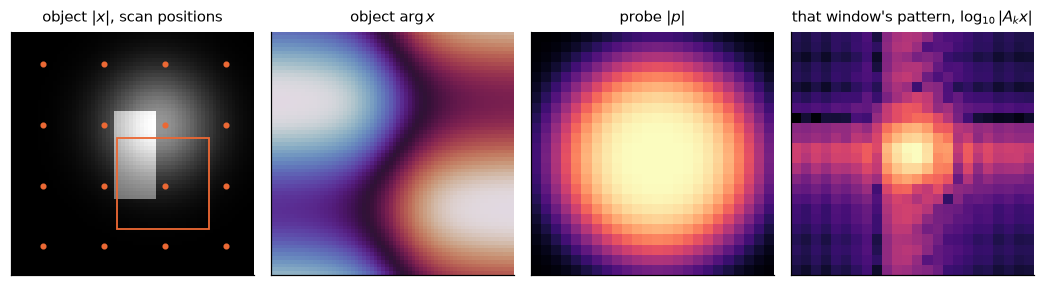

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(9.6, 2.7))
k0 = min(range(len(shifts)), key=lambda k: abs(shifts[k][0]) + abs(shifts[k][1]))
axes[0].imshow(x_true.abs().numpy(), cmap="gray")
axes[0].plot([(N // 2 - sx) % N for _, sx in shifts], [(N // 2 - sy) % N for sy, _ in shifts],
             "o", ms=3, color="#eb6834")                     # the window centres
sy, sx = shifts[k0]                                          # one window, drawn whole
axes[0].add_patch(plt.Rectangle((N // 2 - sx - PROBE // 2 - .5, N // 2 - sy - PROBE // 2 - .5),
                                PROBE, PROBE, fill=False, ec="#eb6834", lw=1.2))
axes[0].set_xlim(-0.5, N - 0.5); axes[0].set_ylim(N - 0.5, -0.5)
axes[0].set_title("object $|x|$, scan positions", fontsize=9.5)
axes[1].imshow(x_true.angle().numpy(), cmap="twilight")
axes[1].set_title(r"object $\arg x$", fontsize=9.5)
axes[2].imshow(probe.abs().numpy(), cmap="magma")
axes[2].set_title("probe $|p|$", fontsize=9.5)
axes[3].imshow(torch.fft.fftshift(b[:, k0 * PROBE:(k0 + 1) * PROBE]).abs().log10().numpy(), cmap="magma")
axes[3].set_title(r"that window's pattern, $\log_{10}|A_k x|$", fontsize=9.5)
for ax in axes:
    ax.grid(False); ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()
plt.show()

## 3. Ten lines of gradient descent

With $A$ and $A^H$ in hand the solver is the textbook iteration

$$x_{k+1} = x_k - \tau\, A^H (A x_k - b), \qquad \tau = \frac{1}{\lVert A\rVert_2^2},$$

whose step size is fixed by the spectral norm — `operator_norm(A, x0)` estimates it by power iteration on $A^H A$, which again needs only the two directions. Starting from $x_0 = 0$, the relative data-fit falls fourteen orders of magnitude in about thirty iterations and then sits on the float32 round-off floor: the scan positions overlap, so $A^H A$ is invertible and the object comes back exactly, amplitude *and* phase.

In [5]:
def descend(op, n_iter=120, tau=None):
    """x <- x - tau A^H (A x - b), from zero; returns the iterate and the loss history."""
    x = torch.zeros(N, N, dtype=torch.complex64)
    scale = float(0.5 * b.abs().pow(2).sum())
    hist = []
    for _ in range(n_iter):
        residual = op @ x - b
        hist.append(float(0.5 * residual.abs().pow(2).sum()) / scale)
        x = x - tau * (op.H @ residual)
    return x, np.array(hist)


norm_A = operator_norm(A, torch.randn(N, N, dtype=torch.complex64), n_iter=60)
tau = 1.0 / norm_A ** 2
t0 = time.perf_counter()
x_hat, hist_ok = descend(A, tau=tau)
dt = time.perf_counter() - t0

print(f"||A||_2 = {norm_A:.4f}  ->  step tau = {tau:.4f}")
print(f"120 iterations in {1e3*dt:.0f} ms")
print(f"relative data fit {hist_ok[0]:.2e} -> {hist_ok[-1]:.2e}")
print(f"relative error on the object: {float((x_hat - x_true).norm() / x_true.norm()):.2e}")

||A||_2 = 1.0468  ->  step tau = 0.9127
120 iterations in 56 ms
relative data fit 1.00e+00 -> 1.33e-14
relative error on the object: 8.98e-08


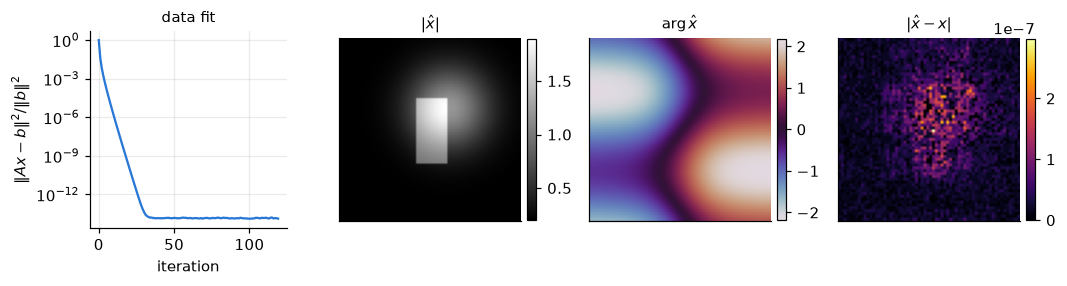

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(9.8, 2.7))
axes[0].semilogy(hist_ok, color="#2a78d6")
axes[0].set(xlabel="iteration", ylabel=r"$\|Ax-b\|^2/\|b\|^2$")
axes[0].set_title("data fit", fontsize=9.5)
for ax, img, title, cmap in [
    (axes[1], x_hat.abs().numpy(), r"$|\hat x|$", "gray"),
    (axes[2], x_hat.angle().numpy(), r"$\arg \hat x$", "twilight"),
    (axes[3], (x_hat - x_true).abs().numpy(), r"$|\hat x - x|$", "inferno"),
]:
    im = ax.imshow(img, cmap=cmap)
    ax.set_title(title, fontsize=9.5); ax.grid(False); ax.set_xticks([]); ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
fig.tight_layout()
plt.show()

## 4. What a wrong adjoint does

The adjoint of $p \odot {\cdot}$ is $\overline{p} \odot {\cdot}$, not $p \odot {\cdot}$. Forgetting that conjugate is the single most common bug in a hand-written forward model, and it is invisible in the forward direction: the operator below produces **bit-identical measurements**, so no simulation, no plot of $Ax$ and no residual will reveal it.

`LinOpFunction(apply, applyT)` wraps the sloppy pair, and everything else in the chain stays the same.

In [7]:
P_sloppy = LinOpFunction(lambda x: probe * x,          # correct forward
                         lambda y: probe * y,          # WRONG: should be probe.conj() * y
                         in_shape=(PROBE, PROBE), out_shape=(PROBE, PROBE))
A_sloppy = LinOpCat([F @ P_sloppy @ LinOpPatch((N, N), (PROBE, PROBE), shifts=s) for s in shifts])

print("forward outputs identical:", torch.equal(A_sloppy @ x_true, b))
print(f"adjoint_error(A)        = {adjoint_error(A, x_true):.2e}")
print(f"adjoint_error(A_sloppy) = {adjoint_error(A_sloppy, x_true):.2e}   <- one line, caught")

forward outputs identical: True
adjoint_error(A)        = 1.58e-10
adjoint_error(A_sloppy) = 1.34e-02   <- one line, caught


sloppy adjoint: data fit 1.00e+00 -> 1.14e+35 at iteration 75, then overflow
same 20 iterations: correct adjoint 1.49e-10, sloppy adjoint 3.26e+08


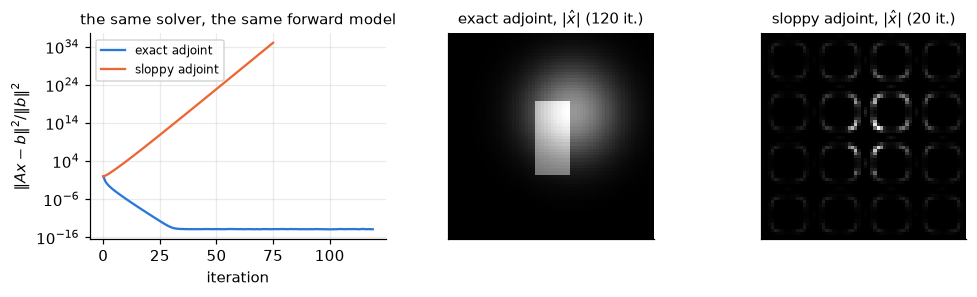

In [8]:
x_bad, hist_bad = descend(A_sloppy, n_iter=120, tau=tau)
finite = np.isfinite(hist_bad)
k_last = int(np.argmax(~finite) - 1) if (~finite).any() else len(hist_bad) - 1
x_bad_20, _ = descend(A_sloppy, n_iter=20, tau=tau)

print(f"sloppy adjoint: data fit {hist_bad[0]:.2e} -> {hist_bad[k_last]:.2e} at iteration {k_last}, "
      f"then overflow")
print(f"same 20 iterations: correct adjoint {hist_ok[20]:.2e}, sloppy adjoint {hist_bad[20]:.2e}")

fig, axes = plt.subplots(1, 3, figsize=(9.4, 2.8))
axes[0].semilogy(hist_ok, color="#2a78d6", label="exact adjoint")
axes[0].semilogy(np.arange(k_last + 1), hist_bad[:k_last + 1], color="#eb6834", label="sloppy adjoint")
axes[0].set(xlabel="iteration", ylabel=r"$\|Ax-b\|^2/\|b\|^2$")
axes[0].set_title("the same solver, the same forward model", fontsize=9.5)
axes[0].legend(fontsize=8)
for ax, img, title in [(axes[1], x_hat.abs().numpy(), r"exact adjoint, $|\hat x|$ (120 it.)"),
                       (axes[2], x_bad_20.abs().numpy(), r"sloppy adjoint, $|\hat x|$ (20 it.)")]:
    ax.imshow(img, cmap="gray"); ax.set_title(title, fontsize=9.5)
    ax.grid(False); ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()
plt.show()

The iteration is no longer a gradient descent on anything: $B^H A$ with $B \neq A$ is not positive semi-definite, the step $1/\lVert A\rVert^2$ no longer protects anything, and the residual grows without bound. A phase error of a few radians in one factor of the chain is enough.

The point of the library is that this class of bug is *checkable*. `adjoint_error(A, x)` computes

$$\frac{\big|\operatorname{Re}\langle A x, y\rangle - \operatorname{Re}\langle x, A^H y\rangle\big|}{\lVert Ax\rVert\,\lVert y\rVert}$$

for a random $y$; it is at round-off when the pair is exact and $O(1)$ when it is not, whatever the operator, and it costs one forward and one adjoint. Every operator in the catalogue is tested this way in `tests/`, so a composition of them is right by construction; the check is there for the ones you write yourself.

## 5. Batching comes for free

The operators act on the trailing axes named by their shapes and leave every leading axis alone, so a batch of objects is the same call on a tensor with one more axis — and the same solver reconstructs all of them at once. No loop, no `for` in the operator, and on a GPU the batch is what fills the device.

In [9]:
BATCH = 8
tilts = [complex(math.cos(0.3 * k), math.sin(0.3 * k)) * (1 - 0.05 * k) for k in range(BATCH)]
x_batch = torch.stack([x_true * t for t in tilts])
b_batch = A @ x_batch
print(f"{tuple(x_batch.shape)} -> {tuple(b_batch.shape)}, in one call")
print("batch item 3 == the same object alone:",
      f"{(b_batch[3] - (A @ x_batch[3])).abs().max().item():.2e}")

x_b = torch.zeros_like(x_batch)
t0 = time.perf_counter()
for _ in range(120):
    x_b = x_b - tau * (A.H @ (A @ x_b - b_batch))
t_batch = time.perf_counter() - t0
err = (x_b - x_batch).flatten(1).norm(dim=1) / x_batch.flatten(1).norm(dim=1)
print(f"{BATCH} objects reconstructed in {1e3*t_batch:.0f} ms "
      f"({1e3*t_batch/BATCH:.0f} ms each, against {1e3*dt:.0f} ms alone)")
print("relative errors:", np.array2string(err.numpy(), precision=2))

(8, 64, 64) -> (8, 24, 384), in one call
batch item 3 == the same object alone: 0.00e+00


8 objects reconstructed in 251 ms (31 ms each, against 56 ms alone)
relative errors: [8.98e-08 9.12e-08 9.16e-08 9.36e-08 9.15e-08 8.85e-08 9.17e-08 9.28e-08]


## 6. Nothing is ever materialised

$A$ maps $64 \times 64$ complex pixels to $16 \times 24 \times 24$ measurements. As a dense matrix that is $9216 \times 4096$ entries — 288 MiB in complex64, for a problem this small. The operator itself holds the probe and 16 index tables, about 10 kB. The dense matrix exists only if you ask for it (`to_matrix`, for inspection on small problems), and the check below confirms that the operator and its matrix are the same map.

The scaling is the whole argument. Keep the probe and the scan step fixed and grow the object: the number of positions grows as the area, so the matrix grows as the *square* of the pixel count while the operator grows linearly with the scan — one 2 × 24 index table per position.

In [10]:
A_tiny = LinOpFft(dim=(-2, -1)) @ LinOpMul(probe[:4, :4]) @ LinOpPatch((8, 8), (4, 4), shifts=(1, -2))
M = to_matrix(A_tiny)
v = torch.randn(8, 8, dtype=torch.complex64)
print(f"to_matrix(A_tiny): {tuple(M.shape)}   "
      f"max |M v - A v| = {(M @ v.reshape(-1) - (A_tiny @ v).reshape(-1)).abs().max().item():.2e}")

print(f"\n{'object':>12} {'positions':>10} {'dense A':>14} {'the operator':>14}")
for n in (64, 128, 256, 512, 1024):
    positions = (n // STEP) ** 2
    dense = positions * PROBE ** 2 * n * n * 8 / 2 ** 30
    held = (probe.numel() * 8 + positions * 2 * PROBE * 8) / 2 ** 20
    print(f"{f'{n}x{n}':>12} {positions:>10} {dense:>10.1f} GiB {held:>11.2f} MiB")

to_matrix(A_tiny): (16, 64)   max |M v - A v| = 1.50e-08

      object  positions        dense A   the operator
       64x64         16        0.3 GiB        0.01 MiB
     128x128         64        4.5 GiB        0.03 MiB
     256x256        256       72.0 GiB        0.10 MiB
     512x512       1024     1152.0 GiB        0.38 MiB
   1024x1024       4096    18432.0 GiB        1.50 MiB


## Summary

* A reconstruction needs $A$ **and** $A^H$; `LinOp` is that pair, and `@`, `+`, `*`, `.H` build new pairs from old ones. `LinOpFft(dim=(-2,-1)) @ LinOpMul(probe) @ LinOpPatch(...)` is a coherent forward model in one line, with its exact adjoint.
* PyTorch's autograd gradient of $\frac12\lVert Ax-b\rVert^2$ is $A^H(Ax-b)$ to round-off — the adjoint is not an optional extra, it *is* the gradient.
* A wrong adjoint is invisible in the forward direction and fatal in the solver: the same 120 iterations that reach a $10^{-14}$ data fit overflow instead. `adjoint_error` separates the two in one line, at the cost of one forward and one adjoint.
* Batch axes are free, and a composed operator is never materialised: at $1024^2$ pixels with a scan to match, the dense matrix would be eighteen terabytes.

**Next.** [Notebook 2](02_what_it_computes.ipynb) states what each operator computes and checks every identity of the algebra and every adjoint of the catalogue against brute force, together with the shape rules, the FFT normalisations, `vmap`/`jacrev`, and the dense pictures of the small operators. [Notebook 3](03_benchmark.ipynb) measures what the abstraction costs: the overhead against hand-written torch, `LinOpPatch` against `LinOpCrop @ LinOpRoll`, batching, `to_matrix`, and precision.